LOGISTIC REGRESSION
Accuracy : 0.9672131147540983
Precision: 0.9688524590163935
Recall   : 0.9672131147540983
F1 Score : 0.9665847206830812


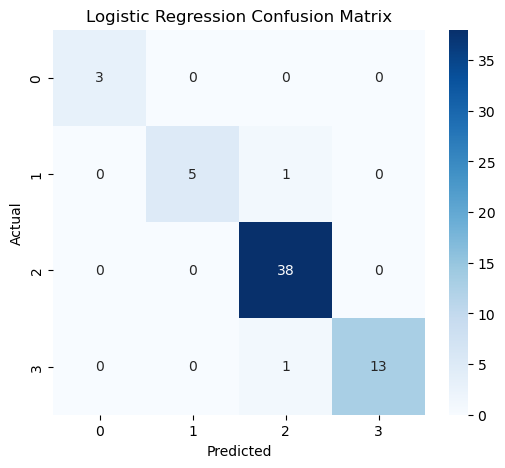

KNN
Accuracy : 0.8852459016393442
Precision: 0.8939509467530816
Recall   : 0.8852459016393442
F1 Score : 0.8773237489084483


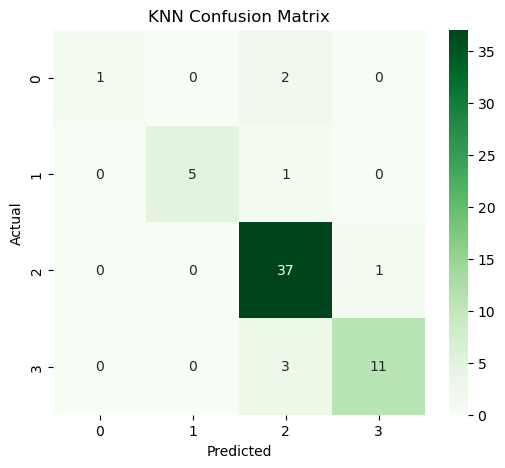

RANDOM FOREST
Accuracy : 0.9836065573770492
Precision: 0.9840269020596889
Recall   : 0.9836065573770492
F1 Score : 0.9820736640408771


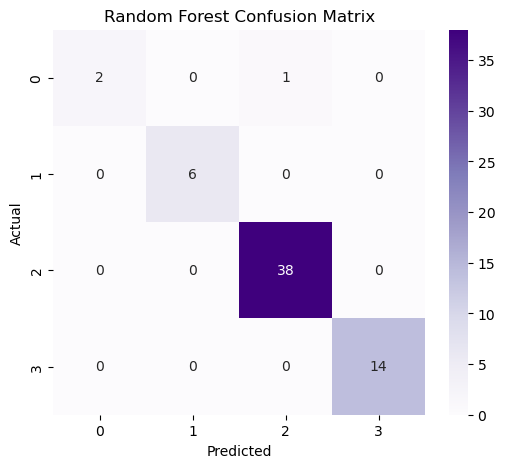



MODEL COMPARISON
             Algorithm  Accuracy  Precision    Recall  F1 Score
2        Random Forest  0.983607   0.984027  0.983607  0.982074
0  Logistic Regression  0.967213   0.968852  0.967213  0.966585
1                  KNN  0.885246   0.893951  0.885246  0.877324


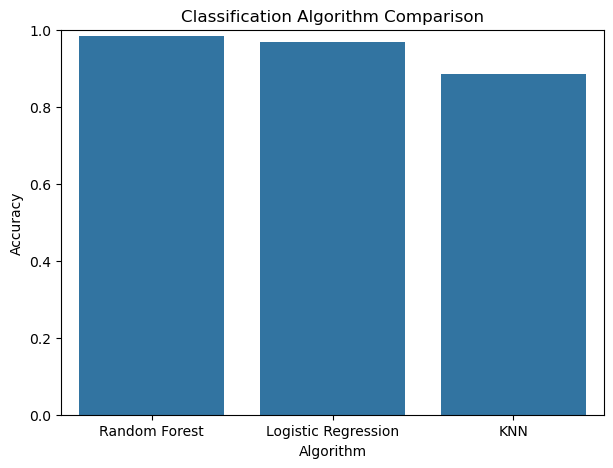

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Supervised Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ---------------------------------------------------
# Load Dataset
# ---------------------------------------------------

las_old = pd.read_csv("WellA.csv")

las_old.columns = [
    'Depth','Gamma-ray','Shale_volume','Restivity',
    'Delta T','Vp','Vs','density',
    'density_calculated','Neutron Porosity',
    'Density_porosity','Poissons_ratio',
    'classification'
]

# ---------------------------------------------------
# Features and Target
# ---------------------------------------------------

X = las_old.drop("classification", axis=1)
y = las_old["classification"]

# ---------------------------------------------------
# Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------------------------
# Feature Scaling
# ---------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------
# Store Results
# ---------------------------------------------------

results = []

# ===================================================
# Logistic Regression
# ===================================================

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, lr_pred)
lr_pre = precision_score(y_test, lr_pred, average='weighted')
lr_rec = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print("Accuracy :", lr_acc)
print("Precision:", lr_pre)
print("Recall   :", lr_rec)
print("F1 Score :", lr_f1)

results.append([
    "Logistic Regression",
    lr_acc,
    lr_pre,
    lr_rec,
    lr_f1
])

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===================================================
# KNN
# ===================================================

print("="*60)
print("KNN")
print("="*60)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)
knn_pre = precision_score(y_test, knn_pred, average='weighted')
knn_rec = recall_score(y_test, knn_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

print("Accuracy :", knn_acc)
print("Precision:", knn_pre)
print("Recall   :", knn_rec)
print("F1 Score :", knn_f1)

results.append([
    "KNN",
    knn_acc,
    knn_pre,
    knn_rec,
    knn_f1
])

cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===================================================
# Random Forest
# ===================================================

print("="*60)
print("RANDOM FOREST")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Random Forest does not require scaling
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred, average='weighted')
rf_rec = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("Accuracy :", rf_acc)
print("Precision:", rf_pre)
print("Recall   :", rf_rec)
print("F1 Score :", rf_f1)

results.append([
    "Random Forest",
    rf_acc,
    rf_pre,
    rf_rec,
    rf_f1
])

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Purples")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ===================================================
# Comparison Table
# ===================================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison)

# ===================================================
# Accuracy Comparison Graph
# ===================================================

plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Accuracy"
)

plt.ylim(0,1)
plt.title("Classification Algorithm Comparison")
plt.ylabel("Accuracy")

plt.show()

Original Shape : (15634, 16)
After removing sparse columns: (15634, 15)

Numeric Columns
['ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'AVG_DP_TUBING', 'AVG_ANNULUS_PRESS', 'AVG_CHOKE_SIZE_P', 'AVG_WHP_P', 'AVG_WHT_P', 'DP_CHOKE_SIZE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL']


LINEAR REGRESSION
MAE : 27.00045417615578
MSE : 2596.514441942192
RMSE: 50.95600496450043
R² Score : 0.9976629107211415


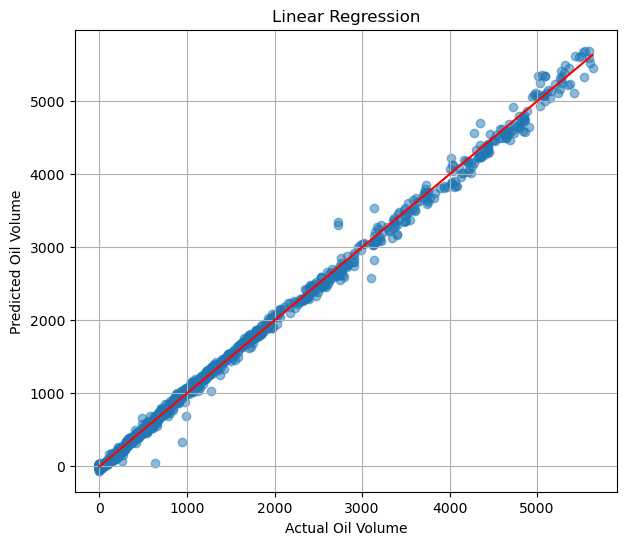



RANDOM FOREST REGRESSION
MAE : 9.747384074192516
MSE : 1122.020669235689
RMSE: 33.49657697788968
R² Score : 0.9989900836158004


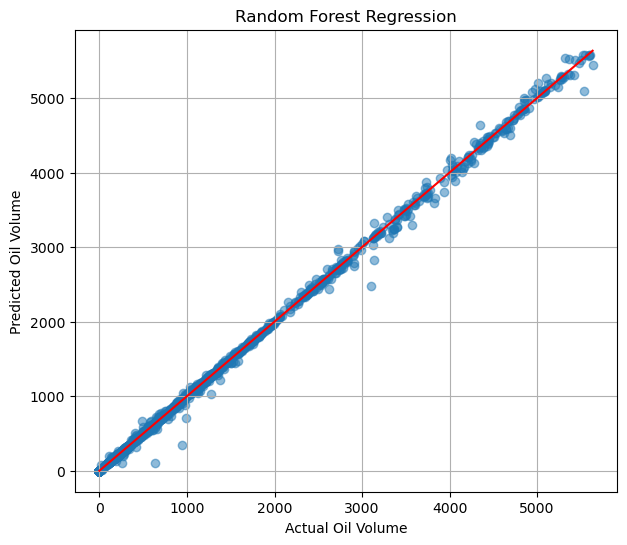



MODEL COMPARISON
           Algorithm        MAE       RMSE  R² Score
1      Random Forest   9.747384  33.496577  0.998990
0  Linear Regression  27.000454  50.956005  0.997663


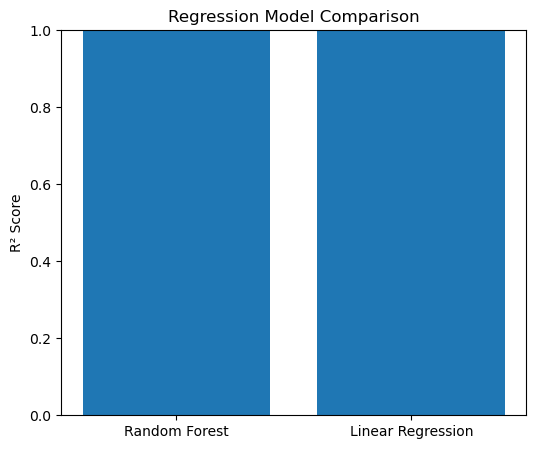

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ====================================================
# LOAD DATA
# ====================================================

df = pd.read_csv("WellB.csv")

print("="*60)
print("Original Shape :", df.shape)
print("="*60)

# ====================================================
# REMOVE COLUMNS HAVING >50% MISSING VALUES
# ====================================================

threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)

print("After removing sparse columns:", df.shape)

# ====================================================
# FILL MISSING VALUES
# ====================================================

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# ====================================================
# ENCODE CATEGORICAL COLUMN
# ====================================================

if "FLOW_KIND" in df.columns:
    df = pd.get_dummies(df, columns=["FLOW_KIND"], drop_first=True)

# ====================================================
# KEEP ONLY NUMERIC DATA
# ====================================================

numeric_df = df.select_dtypes(include=np.number)

print("\nNumeric Columns")
print(numeric_df.columns.tolist())

# ====================================================
# FEATURES & TARGET
# ====================================================

y = numeric_df["BORE_OIL_VOL"]
X = numeric_df.drop(columns=["BORE_OIL_VOL"])

# ====================================================
# TRAIN TEST SPLIT
# ====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ====================================================
# STANDARDIZATION
# ====================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ====================================================
# RESULTS LIST
# ====================================================

results = []

# ====================================================
# LINEAR REGRESSION
# ====================================================

print("\n")
print("="*60)
print("LINEAR REGRESSION")
print("="*60)

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R² Score :", lr_r2)

results.append([
    "Linear Regression",
    lr_mae,
    lr_rmse,
    lr_r2
])

plt.figure(figsize=(7,6))
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.title("Linear Regression")
plt.xlabel("Actual Oil Volume")
plt.ylabel("Predicted Oil Volume")
plt.grid(True)
plt.show()

# ====================================================
# RANDOM FOREST REGRESSION
# ====================================================

print("\n")
print("="*60)
print("RANDOM FOREST REGRESSION")
print("="*60)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Tree models don't require scaling
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score :", rf_r2)

results.append([
    "Random Forest",
    rf_mae,
    rf_rmse,
    rf_r2
])

plt.figure(figsize=(7,6))
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.title("Random Forest Regression")
plt.xlabel("Actual Oil Volume")
plt.ylabel("Predicted Oil Volume")
plt.grid(True)
plt.show()

# ====================================================
# COMPARISON TABLE
# ====================================================

comparison = pd.DataFrame(
    results,
    columns=[
        "Algorithm",
        "MAE",
        "RMSE",
        "R² Score"
    ]
)

comparison = comparison.sort_values(
    by="R² Score",
    ascending=False
)

print("\n")
print("="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison)

# ====================================================
# BAR CHART
# ====================================================

plt.figure(figsize=(6,5))

plt.bar(comparison["Algorithm"], comparison["R² Score"])

plt.ylabel("R² Score")
plt.title("Regression Model Comparison")
plt.ylim(0, 1)

plt.show()

     DATEPRD NPD_WELL_BORE_NAME  ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  \
0  07-Apr-14         15/9-F-1 C            0.0                  0.000   
1  08-Apr-14         15/9-F-1 C            0.0                    NaN   
2  09-Apr-14         15/9-F-1 C            0.0                    NaN   
3  10-Apr-14         15/9-F-1 C            0.0                    NaN   
4  11-Apr-14         15/9-F-1 C            0.0                310.376   

   AVG_DOWNHOLE_TEMPERATURE  AVG_DP_TUBING  AVG_ANNULUS_PRESS  \
0                     0.000          0.000                0.0   
1                       NaN            NaN                0.0   
2                       NaN            NaN                0.0   
3                       NaN            NaN                0.0   
4                    96.876        277.278                0.0   

   AVG_CHOKE_SIZE_P  AVG_WHP_P  AVG_WHT_P  DP_CHOKE_SIZE  BORE_OIL_VOL  \
0           0.00000      0.000       0.00          0.000           0.0   
1           1.00306   

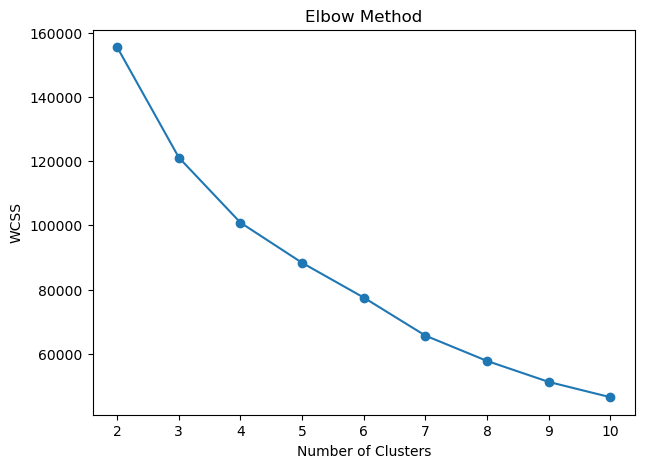


KMeans Cluster Counts
KMeans_Cluster
0    10898
1     2496
2     2240
Name: count, dtype: int64

KMeans Silhouette Score: 0.4214000686832231

DBSCAN Cluster Counts
DBSCAN_Cluster
 1    13252
 2     1898
 0      286
-1       76
 4       62
 5       29
 3       15
 6        8
 7        8
Name: count, dtype: int64
DBSCAN Silhouette Score: 0.3028671240383039


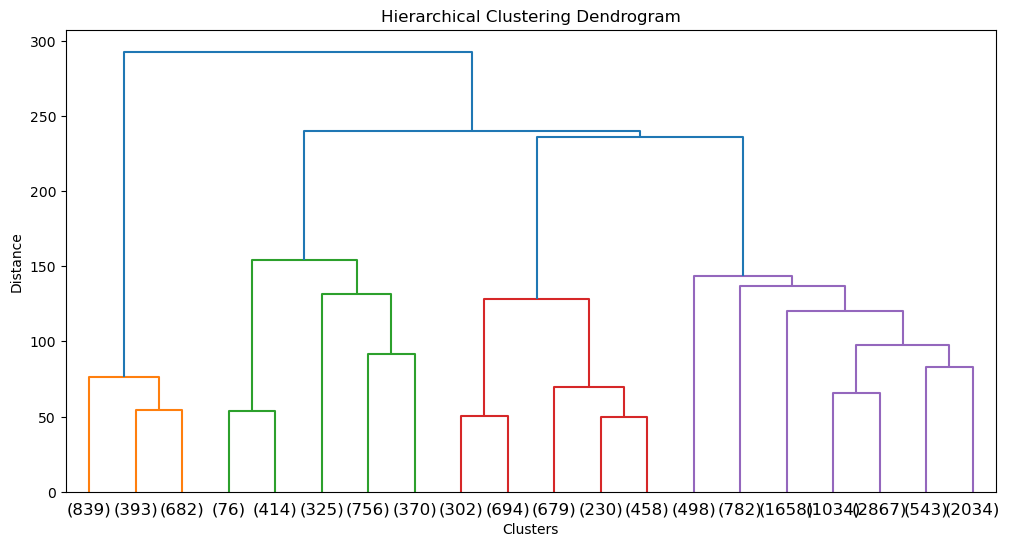


Hierarchical Cluster Counts
Hierarchical_Cluster
0    11779
2     1941
1     1914
Name: count, dtype: int64

Hierarchical Silhouette Score: 0.3892744520304638


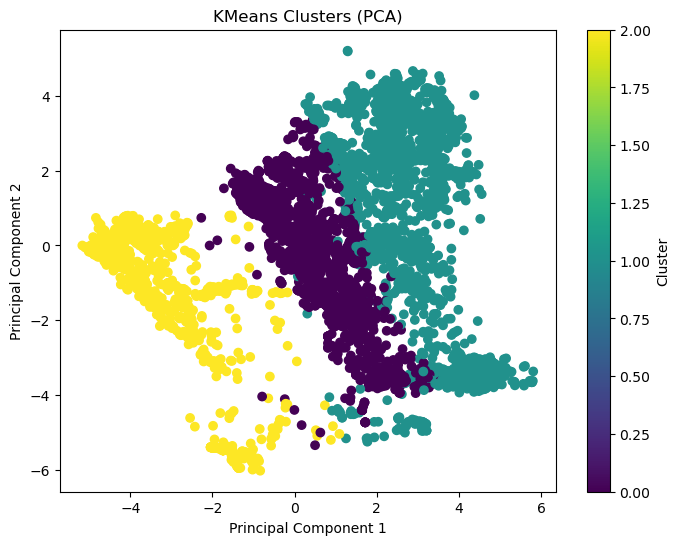


Clustered dataset saved as WellB_Clustered.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("WellB.csv")      # Change filename if needed

print(df.head())

# -----------------------------
# Drop Non-Numeric Columns
# -----------------------------
drop_cols = ["DATEPRD", "NPD_WELL_BORE_NAME", "FLOW_KIND"]

numeric_df = df.drop(columns=drop_cols)

# -----------------------------
# Missing Values
# -----------------------------
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(numeric_df)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================================
# K-MEANS CLUSTERING
# ==========================================================

wcss = []

for i in range(2,11):
    km = KMeans(n_clusters=i,
                random_state=42,
                n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# -----------------------------
# Choose number of clusters
# -----------------------------
k = 3

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("\nKMeans Cluster Counts")
print(df["KMeans_Cluster"].value_counts())

score = silhouette_score(X_scaled, kmeans_labels)
print("\nKMeans Silhouette Score:", score)

# ==========================================================
# DBSCAN
# ==========================================================

dbscan = DBSCAN(
    eps=1.5,
    min_samples=8
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

print("\nDBSCAN Cluster Counts")
print(df["DBSCAN_Cluster"].value_counts())

# Silhouette only if more than one cluster
unique = set(db_labels)

if len(unique) > 2:
    score = silhouette_score(X_scaled, db_labels)
    print("DBSCAN Silhouette Score:", score)

# ==========================================================
# HIERARCHICAL CLUSTERING
# ==========================================================

plt.figure(figsize=(12,6))

Z = linkage(X_scaled, method='ward')

dendrogram(
    Z,
    truncate_mode='lastp',
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

agg = AgglomerativeClustering(n_clusters=3)

agg_labels = agg.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = agg_labels

print("\nHierarchical Cluster Counts")
print(df["Hierarchical_Cluster"].value_counts())

score = silhouette_score(X_scaled, agg_labels)
print("\nHierarchical Silhouette Score:", score)

# ==========================================================
# PCA Visualization
# ==========================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=kmeans_labels,
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clusters (PCA)")
plt.colorbar(label="Cluster")
plt.show()

# ==========================================================
# Save Result
# ==========================================================

df.to_csv("WellB_Clustered.csv", index=False)

print("\nClustered dataset saved as WellB_Clustered.csv")